# Mini-project: a hidden Markov model (the occasionally-dishonest casino)
Hidden state z_t in {fair, loaded}; observation x_t in {1..6}. The casino
sometimes swaps dice. Goal: from the rolls alone, infer WHEN the loaded die
was in play. You'll write forward, backward, and the smoothing posterior.
See slides: Part 3.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

RNG = np.random.default_rng(0)   # fixed seed -> reproducible for everyone

np.set_printoptions(precision=3, suppress=True)
print("numpy", np.__version__)


numpy 2.5.1


In [2]:
# States: 0 = fair, 1 = loaded.  Observations: 0..5  (die faces 1..6).
K, M = 2, 6
pi = np.array([0.5, 0.5])                       # initial state distribution
A  = np.array([[0.95, 0.05],                    # transition: fair sticky, loaded sticky
               [0.10, 0.90]])
B  = np.array([[1/6, 1/6, 1/6, 1/6, 1/6, 1/6],  # fair die: uniform
               [0.1, 0.1, 0.1, 0.1, 0.1, 0.5]]) # loaded die: sixes favored

assert np.allclose(A.sum(1), 1) and np.allclose(B.sum(1), 1)   # rows are distributions
STATE_NAMES = ["fair", "loaded"]


In [3]:
def sample_hmm(pi, A, B, T, rng):
    """Sample (z, x): hidden states z[0..T-1] and observations x[0..T-1].
    This IS the joint factorization from the slides, run left to right."""
    K = len(pi)
    z = np.zeros(T, dtype=int)
    x = np.zeros(T, dtype=int)
    z[0] = rng.choice(K, p=pi)
    x[0] = rng.choice(B.shape[1], p=B[z[0]])
    for t in range(1, T):
        z[t] = rng.choice(K, p=A[z[t-1]])
        x[t] = rng.choice(B.shape[1], p=B[z[t]])
    return z, x


In [4]:
from itertools import product

def loglik_bruteforce(pi, A, B, x):
    """Exact log P(x) by summing over all K**T state sequences. Only for small T."""
    K, T = len(pi), len(x)
    total = 0.0
    for z in product(range(K), repeat=T):
        p = pi[z[0]] * B[z[0], x[0]]
        for t in range(1, T):
            p *= A[z[t-1], z[t]] * B[z[t], x[t]]
        total += p
    return np.log(total)


## Forward algorithm  (scaled, to avoid underflow)
alpha[t, i] = P(x[0:t+1], z_t = i), rescaled each step so it sums to 1.
The scaling constants c[t] give log P(x) = sum(log c) "for free."
Recurrence (before rescaling): alpha[t] = (alpha[t-1] @ A) * B[:, x[t]].
See slide: *Forward algorithm*.

In [5]:
def forward(pi, A, B, x):
    """Returns (alpha, c, loglik): scaled forward vars (T,K), scaling (T,), log P(x)."""
    T, K = len(x), len(pi)
    alpha = np.zeros((T, K))
    c = np.zeros(T)
    # t = 0
    alpha[0] = pi * B[:, x[0]]              # forward init: prior times emission
    c[0] = alpha[0].sum(); alpha[0] /= c[0]
    for t in range(1, T):
        alpha[t] = (alpha[t-1] @ A) * B[:, x[t]]   # forward recursion: mass in from every predecessor, then emission
        c[t] = alpha[t].sum(); alpha[t] /= c[t]
    loglik = np.log(c).sum()
    return alpha, c, loglik


In [6]:
z_s, x_s = sample_hmm(pi, A, B, T=8, rng=np.random.default_rng(1))
_, _, ll = forward(pi, A, B, x_s)
assert np.isclose(ll, loglik_bruteforce(pi, A, B, x_s)), (ll, loglik_bruteforce(pi, A, B, x_s))
print(f"log P(x) = {ll:.4f}  matches brute force ✓  (O(T*K^2) vs O(K^T))")


log P(x) = -12.7022  matches brute force ✓  (O(T*K^2) vs O(K^T))


## Backward algorithm  (same scaling constants c)
beta[t, i] = P(x[t+1:] | z_t = i) — a CONDITIONAL, not a joint. So beta[T-1]=1
(no future left to explain). Reuse c from forward to keep it numerically safe.
See slide: *Backward algorithm*.

In [7]:
def backward(A, B, x, c):
    """Returns scaled beta (T, K), using the forward scaling constants c."""
    T, K = len(x), A.shape[0]
    beta = np.zeros((T, K))
    beta[-1] = 1.0
    for t in range(T-2, -1, -1):
        beta[t] = (A @ (B[:, x[t+1]] * beta[t+1])) / c[t+1]   # backward recursion: evidence from the future, scaled by c[t+1]
    return beta


In [8]:
def posterior(alpha, beta):
    """Smoothing posterior gamma[t, i] = P(z_t = i | x_0:T-1)."""
    gamma = alpha * beta
    gamma /= gamma.sum(axis=1, keepdims=True)     # normalize each timestep to a distribution
    return gamma


In [9]:
alpha, c, _ = forward(pi, A, B, x_s)
beta = backward(A, B, x_s, c)
gamma = posterior(alpha, beta)
assert np.allclose(gamma.sum(axis=1), 1.0)          # each timestep is a distribution
assert gamma.shape == (len(x_s), K)
print("gamma is a valid posterior ✓")


gamma is a valid posterior ✓


log P(x) = -512.66   state-recovery accuracy = 69.00%


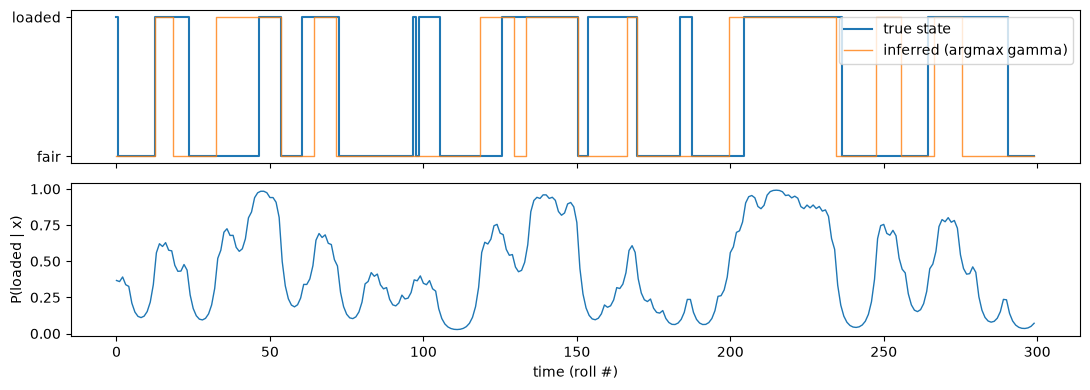

In [10]:
# Long sequence with known ground truth
z_true, x_obs = sample_hmm(pi, A, B, T=300, rng=RNG)
alpha, c, ll = forward(pi, A, B, x_obs)
beta  = backward(A, B, x_obs, c)
gamma = posterior(alpha, beta)
z_hat = gamma.argmax(axis=1)                        # most likely state per timestep

acc = (z_hat == z_true).mean()
print(f"log P(x) = {ll:.2f}   state-recovery accuracy = {acc:.2%}")

fig, ax = plt.subplots(2, 1, figsize=(11, 4), sharex=True)
ax[0].step(range(300), z_true, where="mid", label="true state", lw=1.5)
ax[0].step(range(300), z_hat,  where="mid", label="inferred (argmax gamma)", lw=1, alpha=0.8)
ax[0].set_yticks([0, 1]); ax[0].set_yticklabels(STATE_NAMES); ax[0].legend(loc="upper right")
ax[1].plot(range(300), gamma[:, 1], lw=1)
ax[1].set_ylabel("P(loaded | x)"); ax[1].set_xlabel("time (roll #)")
plt.tight_layout(); plt.show()

assert acc > 0.65, "expected recovery well above the ~53% trivial (majority-class) baseline"


In [11]:
try:
    from hmmlearn.hmm import CategoricalHMM
    m = CategoricalHMM(n_components=K, init_params="", params="")
    m.startprob_, m.transmat_, m.emissionprob_ = pi, A, B
    ref_ll = m.score(x_obs.reshape(-1, 1))
    print(f"our log P(x) = {ll:.4f}   hmmlearn = {ref_ll:.4f}")
    assert np.isclose(ll, ref_ll, atol=1e-6)
    print("matches hmmlearn ✓")
except ImportError:
    print("hmmlearn not installed — skipping external check (optional).")


our log P(x) = -512.6635   hmmlearn = -512.6635
matches hmmlearn ✓


### Extensions (if you finish early) [ADVANCED]
1. Viterbi: the single most-likely PATH (not per-timestep). It's Checkpoint 3
   with cost = -log prob. Compare its path to argmax(gamma) — they can differ.
2. One Baum-Welch (EM) update: use alpha, beta, gamma as the E-step statistics
   to re-estimate (pi, A, B). This is the "model learns itself" step — the open
   hole today's project leaves for tomorrow.
3. Swap categorical B for a Gaussian emission and re-run on a continuous signal.

In [12]:
def viterbi(pi, A, B, x):
    """Most likely state path (log space)."""
    T, K = len(x), len(pi)
    logA, logB, logpi = np.log(A), np.log(B), np.log(pi)
    delta = np.full((T, K), -np.inf)
    psi = np.zeros((T, K), dtype=int)
    delta[0] = logpi + logB[:, x[0]]
    for t in range(1, T):
        for j in range(K):
            scores = delta[t-1] + logA[:, j]
            psi[t, j] = int(np.argmax(scores))
            delta[t, j] = logB[j, x[t]] + scores[psi[t, j]]
    path = [int(np.argmax(delta[-1]))]
    for t in range(T-1, 0, -1):
        path.append(int(psi[t, path[-1]]))
    return list(reversed(path))


In [13]:
def best_path_bruteforce(pi, A, B, x):
    K, T = len(pi), len(x)
    best, best_z = -np.inf, None
    for z in product(range(K), repeat=T):
        lp = np.log(pi[z[0]]) + np.log(B[z[0], x[0]])
        for t in range(1, T):
            lp += np.log(A[z[t-1], z[t]]) + np.log(B[z[t], x[t]])
        if lp > best: best, best_z = lp, list(z)
    return best_z

xs = sample_hmm(pi, A, B, 8, np.random.default_rng(3))[1]
assert viterbi(pi, A, B, xs) == best_path_bruteforce(pi, A, B, xs)
print("Viterbi matches brute-force best path ✓")


Viterbi matches brute-force best path ✓


This toy is a real method. Event segmentation in fMRI (Baldassano et al., 2017,
Neuron) fits an HMM where the hidden state is "which event." GLM-HMMs (Ashwood
et al., 2022, Nat. Neuro.) model animals switching between engaged/disengaged
strategies. Single-trial neural decoding becomes an HMM once you add a
state-transition prior instead of treating timepoints independently.